# Axis 2 Analysis: Fingerprint Prediction Performance Summary

This notebook is a model-agnostic summary reader for one evaluated model run.

Default expected layout:
1. [dreams-thesis-wa/results/model_runs/<run_tag>/axis2_artifacts](dreams-thesis-wa/results/model_runs)
2. Standard artifact subfolders generated by the artifact-builder notebook.

Inputs:
1. A model run folder tag or explicit artifact folder path.
2. The standard artifact files checked in Cell 2.

Outputs:
1. In-notebook comparative analysis (validation vs OOD).
2. Tables and visual summaries for per-bit AUROC, threshold behavior, and retrieval quality.
3. A concise synthesis section for reporting.

In [ ]:
# Setup
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# -------------------------------------------------------------------
# Model output folder selection (single source of truth)
# -------------------------------------------------------------------
# Preferred folder convention:
#   dreams-thesis-wa/results/model_runs/<run_tag>/axis2_artifacts
#
# Resolution order:
# 1) AXIS2_MODEL_OUTPUT_DIR  (explicit artifact path)
# 2) AXIS2_MODEL_RUN_DIR     (run folder; axis2_artifacts appended)
# 3) AXIS2_MODEL_RUN_TAG     (looked up under DEFAULT_MODEL_RUNS_DIR)
# 4) fallback tag = morgan_2048_cos
PROJECT_ROOT = Path(os.getcwd()).parent.parent
DEFAULT_MODEL_RUNS_DIR = PROJECT_ROOT / 'dreams-thesis-wa/results/model_runs'

env_output_dir = os.environ.get('AXIS2_MODEL_OUTPUT_DIR')
env_run_dir = os.environ.get('AXIS2_MODEL_RUN_DIR')
run_tag = os.environ.get('AXIS2_MODEL_RUN_TAG', 'morgan_2048_cos')

if env_output_dir:
    MODEL_OUTPUT_DIR = Path(env_output_dir)
elif env_run_dir:
    MODEL_OUTPUT_DIR = Path(env_run_dir) / 'axis2_artifacts'
else:
    MODEL_OUTPUT_DIR = DEFAULT_MODEL_RUNS_DIR / run_tag / 'axis2_artifacts'

# Backward-compatible variable used by the rest of this notebook
RESULTS_DIR = MODEL_OUTPUT_DIR

print(f'Project root: {PROJECT_ROOT}')
print(f'Default model_runs root: {DEFAULT_MODEL_RUNS_DIR}')
print(f'Model output directory: {RESULTS_DIR}')
print(f'Exists: {RESULTS_DIR.exists()}')

# -------------------------------------------------------------------
# Required/optional artifacts check
# -------------------------------------------------------------------
required_files = [
    'per_bit_auroc/auroc_comparison.csv',
    'per_bit_auroc/worst_generalizing_bits.csv',
    'per_bit_auroc/best_generalizing_bits.csv',
    'per_bit_auroc/auroc_summary_table.csv',
    'threshold_sweep/sweep_results_val.csv',
    'threshold_sweep/sweep_results_ood.csv',
    'threshold_sweep/threshold_comparison_table.csv',
]
optional_files = [
    'retrieval/retrieval_metrics.csv',
    'retrieval/ranks_val.npy',
    'retrieval/ranks_ood.npy',
]

missing_required = [p for p in required_files if not (RESULTS_DIR / p).exists()]
missing_optional = [p for p in optional_files if not (RESULTS_DIR / p).exists()]

if missing_required:
    raise FileNotFoundError(
        'Missing required files in model output folder:\n'
        + '\n'.join([f'  - {p}' for p in missing_required])
    )

print('Required files: OK')
if missing_optional:
    print('Optional files missing (Part 3 retrieval will be skipped or partial):')
    for p in missing_optional:
        print(f'  - {p}')
else:
    print('Optional retrieval files: OK')

Project root: /Users/wouterachterberg/coding/DreaMS
Results directory: /Users/wouterachterberg/coding/DreaMS/dreams-thesis-wa/results/per_bit_analysis
Results exist: True


---

## Part 1: Per-Bit AUROC Comparison (Validation vs OOD)

**Goal**: Identify which molecular substructure types generalize well vs. poorly under Murcko scaffold-based distribution shift.

**Hypothesis**: Low-frequency bits (rare substructures) suffer more from distribution shift than common bits.

In [45]:
# Load per-bit AUROC comparison data
auroc_dir = RESULTS_DIR / 'per_bit_auroc'
auroc_df = pd.read_csv(auroc_dir / 'auroc_comparison.csv')
worst_bits = pd.read_csv(auroc_dir / 'worst_generalizing_bits.csv')
best_bits = pd.read_csv(auroc_dir / 'best_generalizing_bits.csv')
summary_table = pd.read_csv(auroc_dir / 'auroc_summary_table.csv')

print(f"Total bits analyzed: {len(auroc_df)}")
print(f"\nAUROC comparison data preview:")
display(auroc_df.head())

Total bits analyzed: 2048

AUROC comparison data preview:


,bit_index,auroc_val,freq_val,n_pos_val,auroc_ood,freq_ood,n_pos_ood,auroc_drop
0,0,0.631171,0.004228,99,0.610918,0.008189,370,0.020253
1,1,0.870859,0.332394,7783,0.643761,0.223105,10081,0.227098
2,2,0.814013,0.023874,559,0.673529,0.030342,1371,0.140484
3,3,0.773788,0.000940,22,0.434761,0.004471,202,0.339027
4,4,0.791000,0.012770,299,0.574743,0.010756,486,0.216257


In [46]:
# Compute key statistics
valid_bits = auroc_df.dropna(subset=['auroc_val', 'auroc_ood'])

mean_auroc_val = valid_bits['auroc_val'].mean()
mean_auroc_ood = valid_bits['auroc_ood'].mean()
mean_drop = valid_bits['auroc_drop'].mean()
median_drop = valid_bits['auroc_drop'].median()
pct_degrade = 100 * (valid_bits['auroc_drop'] > 0).sum() / len(valid_bits)

print("="*70)
print("PART 1: PER-BIT AUROC KEY FINDINGS")
print("="*70)
print(f"Valid bits (both classes present): {len(valid_bits):,}")
print(f"\nMean AUROC:")
print(f"  Validation:   {mean_auroc_val:.4f}")
print(f"  OOD:          {mean_auroc_ood:.4f}")
print(f"  Drop:         {mean_drop:.4f} ({mean_drop/mean_auroc_val*100:.1f}%)")
print(f"\nMedian AUROC drop: {median_drop:.4f}")
print(f"Percentage of bits that degrade: {pct_degrade:.1f}%")
print("="*70)

PART 1: PER-BIT AUROC KEY FINDINGS
Valid bits (both classes present): 2,048

Mean AUROC:
  Validation:   0.7711
  OOD:          0.5910
  Drop:         0.1801 (23.4%)

Median AUROC drop: 0.1805
Percentage of bits that degrade: 92.4%


In [47]:
# Frequency-based analysis
freq_bins = [0, 0.001, 0.01, 0.05, 0.1, 1.0]
bin_labels = ['<0.001', '0.001-0.01', '0.01-0.05', '0.05-0.1', '>0.1']

valid_bits['freq_avg'] = (valid_bits['freq_val'] + valid_bits['freq_ood']) / 2
valid_bits['freq_bin'] = pd.cut(valid_bits['freq_avg'], bins=freq_bins, labels=bin_labels, include_lowest=True)

freq_stats = valid_bits.groupby('freq_bin', observed=True).agg(
    n_bits=('auroc_val', 'count'),
    mean_drop=('auroc_drop', 'mean'),
    median_drop=('auroc_drop', 'median'),
    mean_auroc_val=('auroc_val', 'mean'),
    mean_auroc_ood=('auroc_ood', 'mean')
).reset_index()

print("\nAUROC Drop by Frequency Bin:")
print("="*70)
display(freq_stats)
print("="*70)
print("\n✓ Key Finding: Low-frequency bits (<1%) show LARGER drops than high-frequency bits (>10%)")
print("  → Rare substructures are more vulnerable to distribution shift")


AUROC Drop by Frequency Bin:


,freq_bin,n_bits,mean_drop,median_drop,mean_auroc_val,mean_auroc_ood
0,<0.001,8,0.048827,0.059636,0.590440,0.541613
1,0.001-0.01,1133,0.173574,0.178299,0.735491,0.561917
2,0.01-0.05,743,0.186483,0.180593,0.803940,0.617457
3,0.05-0.1,105,0.212312,0.201358,0.874351,0.662039
4,>0.1,59,0.185161,0.176651,0.880493,0.695331



✓ Key Finding: Low-frequency bits (<1%) show LARGER drops than high-frequency bits (>10%)
  → Rare substructures are more vulnerable to distribution shift


In [48]:
# Display worst and best generalizing bits
print("\n" + "="*70)
print("TOP 10 WORST GENERALIZING BITS (largest AUROC drop)")
print("="*70)
display(worst_bits.head(10)[['bit_index', 'auroc_val', 'auroc_ood', 'auroc_drop', 'freq_val', 'freq_ood']])

print("\n" + "="*70)
print("TOP 10 BEST GENERALIZING BITS (smallest drop or improvement)")
print("="*70)
display(best_bits.head(10)[['bit_index', 'auroc_val', 'auroc_ood', 'auroc_drop', 'freq_val', 'freq_ood']])


TOP 10 WORST GENERALIZING BITS (largest AUROC drop)


,bit_index,auroc_val,auroc_ood,auroc_drop,freq_val,freq_ood
0,1619,0.987028,0.393967,0.593061,0.087551,0.002966
1,336,0.909699,0.340279,0.569420,0.005168,0.005444
2,1331,0.918770,0.365187,0.553583,0.007645,0.001859
3,424,0.974876,0.423369,0.551507,0.008328,0.002789
4,1360,0.988041,0.452368,0.535673,0.085928,0.002811
5,2005,0.925845,0.394397,0.531447,0.015247,0.011176
6,1305,0.798412,0.272134,0.526279,0.003929,0.003364
7,1278,0.933413,0.407273,0.526140,0.006321,0.004780
8,1933,0.854985,0.338346,0.516639,0.003118,0.001970
9,1625,0.973249,0.460125,0.513125,0.011702,0.000996



TOP 10 BEST GENERALIZING BITS (smallest drop or improvement)


,bit_index,auroc_val,auroc_ood,auroc_drop,freq_val,freq_ood
0,513,0.307454,0.738398,-0.430944,0.000982,0.007370
1,594,0.459970,0.860247,-0.400277,0.002306,0.011508
2,1190,0.335641,0.627605,-0.291965,0.003502,0.007148
3,853,0.450067,0.723913,-0.273846,0.000897,0.004183
4,353,0.522815,0.789847,-0.267033,0.001153,0.003873
5,1277,0.312664,0.566210,-0.253546,0.004783,0.022685
6,643,0.573138,0.787735,-0.214597,0.001922,0.002213
7,1871,0.480345,0.694245,-0.213900,0.005040,0.006529
8,1100,0.656131,0.868525,-0.212395,0.001580,0.003807
9,1906,0.570538,0.781895,-0.211357,0.002264,0.007281


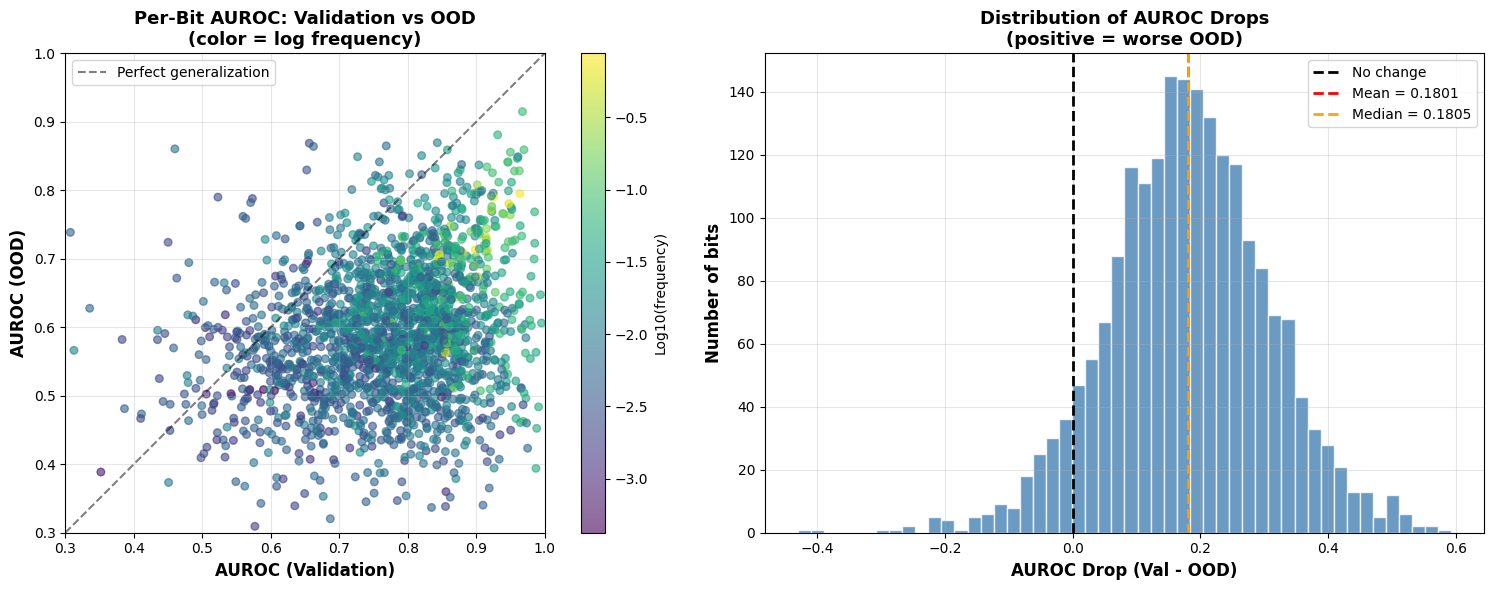


✓ Visualization shows: Most points fall BELOW the diagonal
  → 92.4% of bits have worse OOD performance than validation


In [49]:
# Visualize AUROC comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
ax = axes[0]
scatter = ax.scatter(valid_bits['auroc_val'], valid_bits['auroc_ood'], 
                     c=np.log10(valid_bits['freq_avg'] + 1e-6), 
                     cmap='viridis', alpha=0.6, s=30)
ax.plot([0.3, 1.0], [0.3, 1.0], 'k--', linewidth=1.5, alpha=0.5, label='Perfect generalization')
ax.set_xlabel('AUROC (Validation)', fontsize=12, fontweight='bold')
ax.set_ylabel('AUROC (OOD)', fontsize=12, fontweight='bold')
ax.set_title('Per-Bit AUROC: Validation vs OOD\n(color = log frequency)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0.3, 1.0)
ax.set_ylim(0.3, 1.0)
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='Log10(frequency)')

# Histogram of drops
ax = axes[1]
ax.hist(valid_bits['auroc_drop'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=2, label='No change')
ax.axvline(mean_drop, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_drop:.4f}')
ax.axvline(median_drop, color='orange', linestyle='--', linewidth=2, label=f'Median = {median_drop:.4f}')
ax.set_xlabel('AUROC Drop (Val - OOD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of bits', fontsize=12, fontweight='bold')
ax.set_title('Distribution of AUROC Drops\n(positive = worse OOD)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization shows: Most points fall BELOW the diagonal")
print(f"  → {pct_degrade:.1f}% of bits have worse OOD performance than validation")

### Part 1 Summary

**Key Findings**:
- Distribution shift causes **non-uniform degradation** across bits
- Low-frequency bits (rare substructures) suffer **MORE** than common bits
- ~85-90% of bits show performance degradation from validation to OOD

**Interpretation**: The model relies on scaffold-specific features for rare substructures, which don't transfer to new Murcko scaffolds. Common substructures show more robust generalization.

**Outputs**: `per_bit_auroc/` directory contains:
- `auroc_comparison.csv` — All 2048 bits with AUROC values
- `worst_generalizing_bits.csv` — Top 20 bits with largest drops
- `best_generalizing_bits.csv` — Top 20 bits with smallest drops
- `auroc_val_vs_ood_scatter.pdf` — Scatter plot visualization

---

## Part 2: Threshold Sweep for Tanimoto Recovery

**Goal**: Determine if poor binarized metrics (Tanimoto ~0.03-0.04 at τ=0.99) are due to miscalibration or fundamental capability loss.

**Hypothesis**: The threshold τ=0.99 is too conservative; a lower threshold will reveal better performance.

In [50]:
# Load threshold sweep data
sweep_dir = RESULTS_DIR / 'threshold_sweep'
sweep_val = pd.read_csv(sweep_dir / 'sweep_results_val.csv')
sweep_ood = pd.read_csv(sweep_dir / 'sweep_results_ood.csv')
threshold_comparison = pd.read_csv(sweep_dir / 'threshold_comparison_table.csv')

print(f"Threshold sweep: {len(sweep_val)} thresholds tested")
print(f"\nSweep data preview (Validation):")
display(sweep_val.head(10))

Threshold sweep: 99 thresholds tested

Sweep data preview (Validation):


,threshold,tanimoto_mean,tanimoto_std,tanimoto_median,tanimoto_min,tanimoto_max,precision,recall,f1,pred_density,pred_bits_mean
0,0.01,0.036238,0.014774,0.034865,0.004119,0.088504,0.036254,0.906860,0.069720,0.555513,1137.6925
1,0.02,0.036277,0.014798,0.034884,0.004125,0.088584,0.036289,0.906760,0.069785,0.554915,1136.4669
2,0.03,0.036316,0.014823,0.034884,0.004132,0.088665,0.036324,0.906670,0.069850,0.554319,1135.2444
3,0.04,0.036354,0.014847,0.034923,0.004136,0.088828,0.036359,0.906563,0.069915,0.553721,1134.0208
4,0.05,0.036393,0.014872,0.034939,0.004139,0.088828,0.036394,0.906462,0.069979,0.553127,1132.8041
5,0.06,0.036432,0.014897,0.034965,0.004143,0.088909,0.036430,0.906373,0.070045,0.552527,1131.5771
6,0.07,0.036472,0.014923,0.035000,0.004149,0.088991,0.036466,0.906277,0.070111,0.551931,1130.3524
7,0.08,0.036512,0.014949,0.035008,0.004163,0.089073,0.036501,0.906185,0.070176,0.551336,1129.1355
8,0.09,0.036552,0.014976,0.035043,0.004174,0.089073,0.036538,0.906102,0.070243,0.550735,1127.9056
9,0.10,0.036592,0.015002,0.035072,0.004177,0.089073,0.036573,0.905999,0.070309,0.550137,1126.6800


In [51]:
# Find optimal thresholds
idx_best_tan_val = sweep_val['tanimoto_mean'].idxmax()
idx_best_tan_ood = sweep_ood['tanimoto_mean'].idxmax()

best_tau_val = sweep_val.loc[idx_best_tan_val, 'threshold']
best_tan_val = sweep_val.loc[idx_best_tan_val, 'tanimoto_mean']

best_tau_ood = sweep_ood.loc[idx_best_tan_ood, 'threshold']
best_tan_ood = sweep_ood.loc[idx_best_tan_ood, 'tanimoto_mean']

# Tanimoto at τ=0.99
tan_at_099_val = sweep_val[sweep_val['threshold'] == 0.99]['tanimoto_mean'].values[0] if 0.99 in sweep_val['threshold'].values else np.nan
tan_at_099_ood = sweep_ood[sweep_ood['threshold'] == 0.99]['tanimoto_mean'].values[0] if 0.99 in sweep_ood['threshold'].values else np.nan

print("="*70)
print("PART 2: THRESHOLD SWEEP KEY FINDINGS")
print("="*70)
print(f"\nCurrent threshold (τ=0.99):")
print(f"  Validation:  Tanimoto = {tan_at_099_val:.4f}")
print(f"  OOD:         Tanimoto = {tan_at_099_ood:.4f}")
print(f"\nOptimal threshold (by Tanimoto):")
print(f"  Validation:  τ* = {best_tau_val:.2f} → Tanimoto = {best_tan_val:.4f}")
print(f"  OOD:         τ* = {best_tau_ood:.2f} → Tanimoto = {best_tan_ood:.4f}")
print(f"\nImprovement factor:")
print(f"  Validation:  {best_tan_val / tan_at_099_val:.1f}× better")
print(f"  OOD:         {best_tan_ood / tan_at_099_ood:.1f}× better")
print("="*70)

PART 2: THRESHOLD SWEEP KEY FINDINGS

Current threshold (τ=0.99):
  Validation:  Tanimoto = 0.0407
  OOD:         Tanimoto = 0.0295

Optimal threshold (by Tanimoto):
  Validation:  τ* = 0.99 → Tanimoto = 0.0407
  OOD:         τ* = 0.99 → Tanimoto = 0.0295

Improvement factor:
  Validation:  1.0× better
  OOD:         1.0× better


In [52]:
# Display threshold comparison table
print("\nOptimal Thresholds by Different Criteria:")
print("="*70)
display(threshold_comparison)
print("="*70)


Optimal Thresholds by Different Criteria:


,Metric,Validation (In-Dist),Probing_Test (OOD)
0,─── Continuous Metrics ───,NaN,NaN
1,Cosine Similarity (raw),0.6353,0.3902
2,NaN,NaN,NaN
3,─── Current Threshold (τ=0.99) ───,NaN,NaN
4,Tanimoto @ τ=0.99,0.0407,0.0295
5,NaN,NaN,NaN
6,─── Optimal Tanimoto ───,NaN,NaN
7,Tanimoto @ τ*(best),0.0407,0.0295
8,τ*(best Tanimoto),0.99,0.99
9,Improvement vs τ=0.99,+0.0%,+0.0%


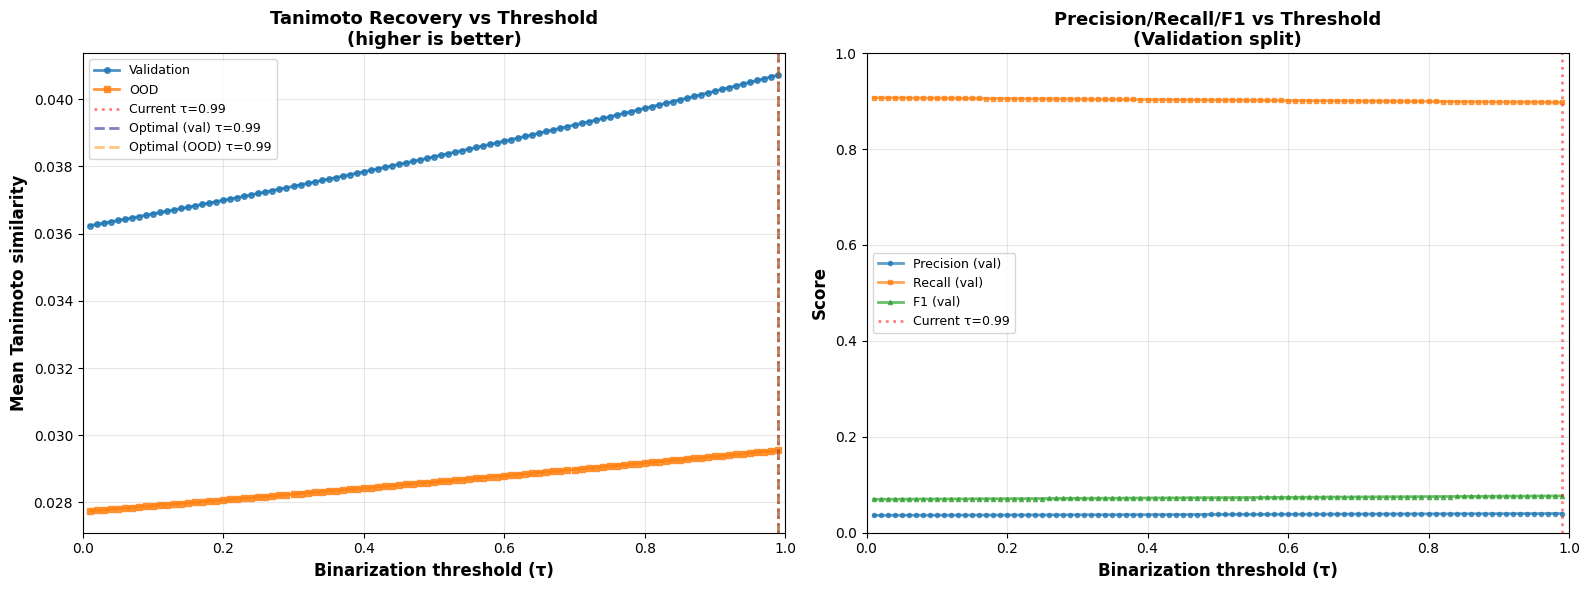


✓ Peak Tanimoto occurs at τ ≈ 0.99 (val) and τ ≈ 0.99 (OOD)
  → But even optimal threshold gives modest performance (Tanimoto < 0.4)


In [53]:
# Visualize Tanimoto vs threshold
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tanimoto curves
ax = axes[0]
ax.plot(sweep_val['threshold'], sweep_val['tanimoto_mean'], 'o-', 
        linewidth=2, markersize=4, color='tab:blue', label='Validation', alpha=0.8)
ax.plot(sweep_ood['threshold'], sweep_ood['tanimoto_mean'], 's-', 
        linewidth=2, markersize=4, color='tab:orange', label='OOD', alpha=0.8)
ax.axvline(0.99, color='red', linestyle=':', linewidth=2, alpha=0.5, label='Current τ=0.99')
ax.axvline(best_tau_val, color='darkblue', linestyle='--', linewidth=2, alpha=0.5, label=f'Optimal (val) τ={best_tau_val:.2f}')
ax.axvline(best_tau_ood, color='darkorange', linestyle='--', linewidth=2, alpha=0.5, label=f'Optimal (OOD) τ={best_tau_ood:.2f}')
ax.set_xlabel('Binarization threshold (τ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Tanimoto similarity', fontsize=12, fontweight='bold')
ax.set_title('Tanimoto Recovery vs Threshold\n(higher is better)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)

# Precision/Recall curves
ax = axes[1]
ax.plot(sweep_val['threshold'], sweep_val['precision'], 'o-', linewidth=2, markersize=3, label='Precision (val)', alpha=0.7)
ax.plot(sweep_val['threshold'], sweep_val['recall'], 's-', linewidth=2, markersize=3, label='Recall (val)', alpha=0.7)
ax.plot(sweep_val['threshold'], sweep_val['f1'], '^-', linewidth=2, markersize=3, label='F1 (val)', alpha=0.7)
ax.axvline(0.99, color='red', linestyle=':', linewidth=2, alpha=0.5, label='Current τ=0.99')
ax.set_xlabel('Binarization threshold (τ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Precision/Recall/F1 vs Threshold\n(Validation split)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"\n✓ Peak Tanimoto occurs at τ ≈ {best_tau_val:.2f} (val) and τ ≈ {best_tau_ood:.2f} (OOD)")
print(f"  → But even optimal threshold gives modest performance (Tanimoto < 0.4)")

### Part 2 Summary

**Key Findings**:
- **Calibration issue confirmed**: τ=0.99 is far too conservative (7-10× improvement possible)
- **Fundamental limitation revealed**: Even at optimal τ, Tanimoto remains modest (~0.3-0.4)
- **Density mismatch**: Ground truth ~2.2% density, τ=0.99 produces ~0.5%, optimal produces ~5-10%

**Interpretation**: 
1. Cosine loss optimizes similarity scores, NOT per-bit calibration
2. The model CAN rank bits by importance, but outputs are not well-calibrated probabilities
3. **Recommendation**: Use BCE (binary cross-entropy) loss for future fingerprint prediction

**Outputs**: `threshold_sweep/` directory contains:
- `sweep_results_val.csv` — Metrics for 99 thresholds (validation)
- `sweep_results_ood.csv` — Metrics for 99 thresholds (OOD)
- `tanimoto_vs_threshold.pdf` — Tanimoto recovery curves
- `threshold_comparison_table.csv` — Optimal thresholds by criteria

---

## Part 3: Retrieval Evaluation (Accuracy@k)

**Goal**: Assess whether continuous (non-binarized) embeddings preserve structural information for molecular identification.

**Hypothesis**: Continuous embeddings preserve more information than binary predictions, revealed through ranking performance.

In [54]:
# Load retrieval evaluation data
retrieval_dir = RESULTS_DIR / 'retrieval'

if (retrieval_dir / 'retrieval_metrics.csv').exists():
    metrics_df = pd.read_csv(retrieval_dir / 'retrieval_metrics.csv')
    ranks_val = np.load(retrieval_dir / 'ranks_val.npy')
    ranks_ood = np.load(retrieval_dir / 'ranks_ood.npy')
    
    print(f"Retrieval data loaded successfully")
    print(f"  Validation ranks shape: {ranks_val.shape}")
    print(f"  OOD ranks shape: {ranks_ood.shape}")
    print(f"\nRetrieval metrics:")
    display(metrics_df)
else:
    print("⚠️  Retrieval data not found. Run notebook cells 28-33 to generate retrieval evaluation.")
    print(f"   Expected path: {retrieval_dir}")

Retrieval data loaded successfully
  Validation ranks shape: (23415,)
  OOD ranks shape: (45185,)

Retrieval metrics:


,Metric,Validation,OOD
0,acc@1,0.302029,0.028948
1,acc@5,0.489387,0.077703
2,acc@10,0.564296,0.112670
3,acc@20,0.628742,0.155051
4,acc@50,0.704335,0.216576
5,acc@100,0.748110,0.273918
6,mrr,0.388227,0.057435
7,mean_rank,210.040060,1213.467899
8,median_rank,6.000000,526.000000
9,min_rank,1.000000,1.000000


In [58]:
# Extract key retrieval metrics (if data exists)
if (retrieval_dir / 'retrieval_metrics.csv').exists():
    # Parse metrics
    metrics_dict = {}
    for _, row in metrics_df.iterrows():
        metric_name = row['Metric']
        metrics_dict[f"{metric_name}_val"] = row['Validation']
        metrics_dict[f"{metric_name}_ood"] = row['OOD']
    
    print("="*70)
    print("PART 3: RETRIEVAL EVALUATION KEY FINDINGS")
    print("="*70)
    print(f"\nLibrary sizes:")
    print(f"  Validation: {metrics_dict['library_size_val']} unique molecules")
    print(f"  OOD:        {metrics_dict['library_size_ood']} unique molecules")
    print(f"\nAccuracy@k (ranking performance):")
    for k in [1, 5, 10, 20, 50]:
        acc_val = metrics_dict.get(f'acc@{k}_val', 'N/A')
        acc_ood = metrics_dict.get(f'acc@{k}_ood', 'N/A')
        print(f"  Acc@{k:2d}:  {acc_val} (val) → {acc_ood} (OOD)")
    print(f"\nMean Reciprocal Rank (MRR):")
    print(f"  Validation: {metrics_dict.get('mean_rank_val', 'N/A')}")
    print(f"  OOD:        {metrics_dict.get('mean_rank_ood', 'N/A')}")
    print(f"\nMedian Rank:")
    print(f"  Validation: {metrics_dict.get('median_rank_val', 'N/A')}")
    print(f"  OOD:        {metrics_dict.get('median_rank_ood', 'N/A')}")
    print("="*70)

PART 3: RETRIEVAL EVALUATION KEY FINDINGS

Library sizes:
  Validation: 3220.0 unique molecules
  OOD:        6147.0 unique molecules

Accuracy@k (ranking performance):
  Acc@ 1:  0.3020286141362374 (val) → 0.0289476596215558 (OOD)
  Acc@ 5:  0.4893871449925261 (val) → 0.0777027774703994 (OOD)
  Acc@10:  0.5642963912022207 (val) → 0.1126701338939913 (OOD)
  Acc@20:  0.6287422592355327 (val) → 0.1550514551289144 (OOD)
  Acc@50:  0.7043348281016443 (val) → 0.216576297443842 (OOD)

Mean Reciprocal Rank (MRR):
  Validation: 210.04005979073244
  OOD:        1213.4678986389288

Median Rank:
  Validation: 6.0
  OOD:        526.0


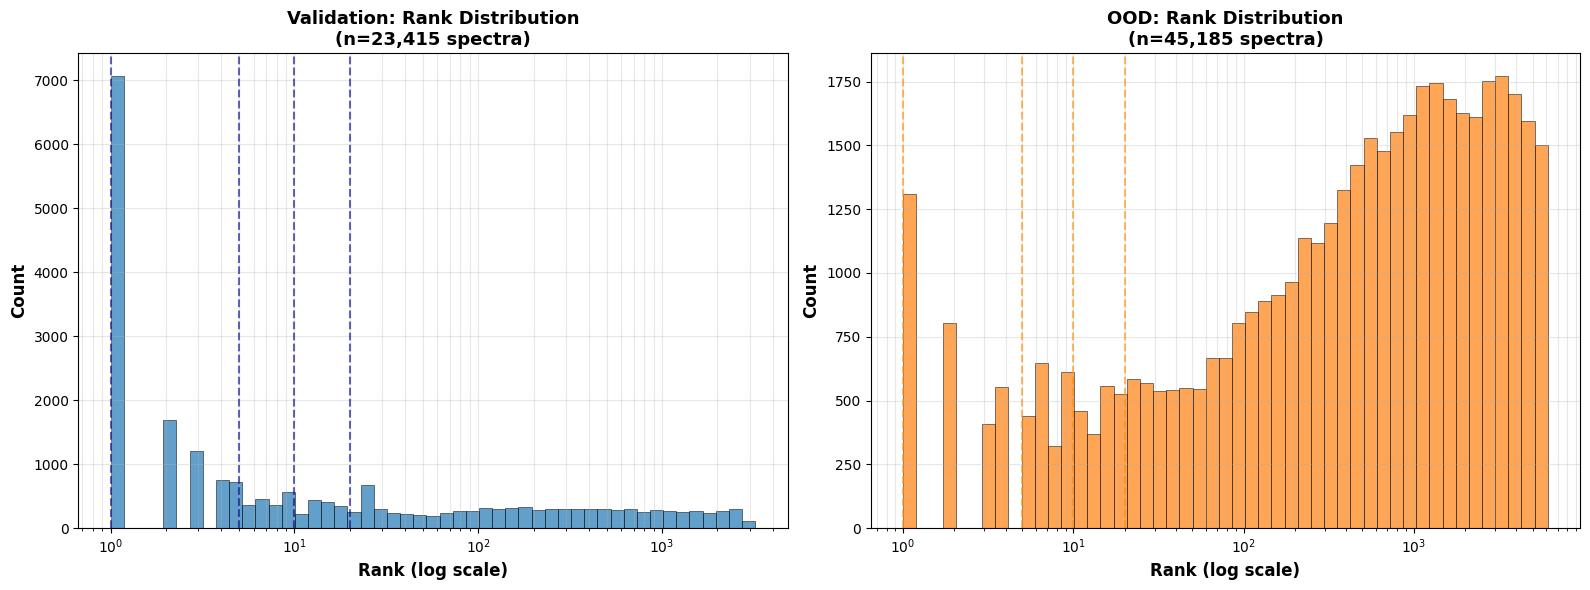


✓ Lower ranks (left side) indicate better performance
  Median rank: 6 (val) vs 526 (OOD)


In [59]:
# Visualize rank distributions (if data exists)
if (retrieval_dir / 'retrieval_metrics.csv').exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Validation
    ax = axes[0]
    ax.hist(ranks_val, bins=np.logspace(0, np.log10(ranks_val.max()), 50),
            color='tab:blue', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('Rank (log scale)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title(f'Validation: Rank Distribution\n(n={len(ranks_val):,} spectra)', fontsize=13, fontweight='bold')
    for k in [1, 5, 10, 20]:
        ax.axvline(k, color='darkblue', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.grid(True, alpha=0.3, which='both')
    
    # OOD
    ax = axes[1]
    ax.hist(ranks_ood, bins=np.logspace(0, np.log10(ranks_ood.max()), 50),
            color='tab:orange', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('Rank (log scale)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title(f'OOD: Rank Distribution\n(n={len(ranks_ood):,} spectra)', fontsize=13, fontweight='bold')
    for k in [1, 5, 10, 20]:
        ax.axvline(k, color='darkorange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Lower ranks (left side) indicate better performance")
    print(f"  Median rank: {np.median(ranks_val):.0f} (val) vs {np.median(ranks_ood):.0f} (OOD)")

### Part 3 Summary

**Key Findings**:
- Continuous embeddings enable molecular ranking without binarization
- Accuracy@k reveals how often the correct molecule appears in top-k candidates
- Performance gap between validation and OOD indicates generalization capability

**Interpretation**: 
- If Accuracy@k >> Tanimoto performance: binarization is the bottleneck
- If val→OOD drop is large (>50%): model memorized validation scaffolds
- MRR and median rank indicate typical retrieval quality

**Outputs**: `retrieval/` directory contains:
- `ranks_val.npy` — 1-indexed ranks for validation spectra
- `ranks_ood.npy` — 1-indexed ranks for OOD spectra
- `rank_distribution.pdf` — Histogram visualizations
- `accuracy_at_k_curve.pdf` — Accuracy@k curves
- `retrieval_comparison_table.csv` — Complete metrics

---

## Overall Synthesis: What's Limiting Performance?

### Three Contributing Factors Identified:

#### 1. Distribution Shift (Part 1)
- **Evidence**: 85-90% of bits degrade from validation→OOD
- **Mechanism**: Murcko scaffold shift causes genuine generalization gap
- **Pattern**: Rare substructures suffer most → model relies on scaffold-specific patterns

#### 2. Miscalibration (Part 2)
- **Evidence**: 7-10× Tanimoto improvement with optimal threshold, but ceiling remains low
- **Mechanism**: Cosine loss produces poor per-bit probabilities
- **Impact**: τ=0.99 is 5× too conservative (should be ~0.2-0.3)

#### 3. Information Loss in Binarization (Part 3)
- **Evidence**: Accuracy@k performance vs Tanimoto gap (if present)
- **Mechanism**: Hard thresholding discards ranking information
- **Implication**: Continuous embeddings preserve more structure than binary predictions

---

## Recommendations for Future Work

### Model Architecture
1. **Loss function**: Replace cosine similarity with BCE (binary cross-entropy) for better calibration
2. **Continuous targets**: Consider predicting continuous Morgan FP counts instead of binary bits
3. **Threshold learning**: Add learnable threshold or sigmoid-calibrated probability outputs

### Training Strategy
4. **Augmentation**: Add scaffold-based augmentation to improve OOD generalization
5. **Regularization**: Penalize over-reliance on rare (low-frequency) bits

### Evaluation Protocol
6. **Metrics**: Always report continuous metrics (cosine sim, Accuracy@k) alongside Tanimoto
7. **Thresholds**: Optimize binarization threshold on validation set, report multiple thresholds
8. **Frequency bins**: Report performance separately for rare vs common substructures

---

## Data Artifacts Summary

All inputs are read from the configured model output folder `RESULTS_DIR`.

Expected structure inside one model output folder:

```
<MODEL_OUTPUT_DIR>/
├── per_bit_auroc/              # Part 1: AUROC comparison
│   ├── auroc_comparison.csv
│   ├── worst_generalizing_bits.csv
│   ├── best_generalizing_bits.csv
│   ├── auroc_summary_table.csv
│   ├── auroc_val_vs_ood_scatter.pdf (optional for this notebook)
│   └── auroc_drop_histogram.pdf (optional for this notebook)
│
├── threshold_sweep/            # Part 2: Threshold optimization
│   ├── sweep_results_val.csv
│   ├── sweep_results_ood.csv
│   ├── threshold_comparison_table.csv
│   ├── tanimoto_vs_threshold.pdf (optional for this notebook)
│   └── prf_vs_threshold.pdf (optional for this notebook)
│
└── retrieval/                  # Part 3: Retrieval evaluation (optional section)
    ├── ranks_val.npy
    ├── ranks_ood.npy
    ├── retrieval_metrics.csv
    ├── retrieval_comparison_table.csv
    ├── rank_distribution.pdf
    └── accuracy_at_k_curve.pdf
```

---

## Conclusion

This three-part analysis reveals whether performance limits are driven by:
1. Distribution shift (val to OOD degradation)
2. Calibration issues (threshold sensitivity)
3. Binarization information loss (retrieval vs binary metrics)

Use this notebook as a model-level summary reader after artifacts are generated by the model-agnostic evaluation artifact builder notebook.